In [6]:
import numpy as np

In [7]:
class Perceptron:

    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.b_ = np.float64(0.)
        self.errors_ = []

        for _ in range(self.n_iter):
            errors = 0
            for x_i, target in zip(X, y):
                update = self.eta * (target - self.predict(x_i))
                self.w_ += update * x_i
                self.b_ += update
                errors += int(update != 0.0)
            self.errors_.append(errors)
        
        return self # Связывание методов в цепочку
    
    def net_input(self, X):
        return np.dot(X, self.w_) + self.b_
    
    def predict(self, X):
        return np.where(self.net_input(X) >= 0.0, 1, 0)

In [8]:
import os
import pandas as pd

df = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data", header=None)
df.tail()

,0,1,2,3,4
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


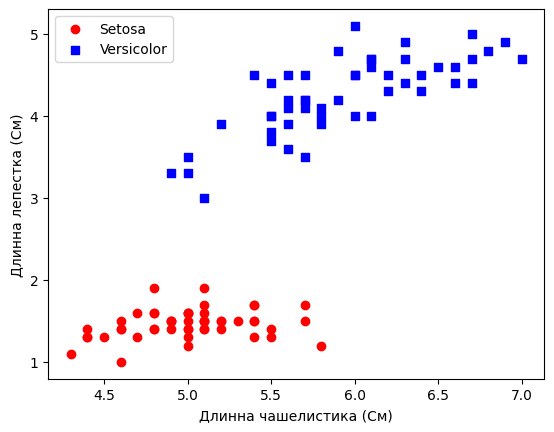

In [9]:
import matplotlib.pyplot as plt

y = df.iloc[0:100, 4].values
y = np.where(y == 'Iris-setosa', 0, 1)

X = df.iloc[0:100, [0, 2]].values

plt.scatter(X[:50, 0], X[:50, 1],
            color='red', marker='o', label='Setosa')

plt.scatter(X[50:100, 0], X[50:100, 1],
            color='blue', marker='s', label='Versicolor')

plt.xlabel('Длинна чашелистика (См)')
plt.ylabel('Длинна лепестка (См)')

plt.legend(loc='upper left')
plt.show()

In [10]:
X.shape, y.shape

((100, 2), (100,))

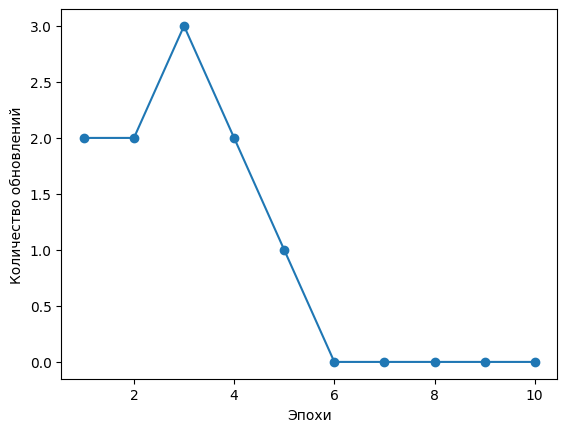

In [11]:
ppn = Perceptron(eta=0.1, n_iter=10)
ppn.fit(X, y)

plt.plot(range(1, len(ppn.errors_) + 1),
         ppn.errors_, marker='o')

plt.xlabel('Эпохи')
plt.ylabel('Количество обновлений')
plt.show()

In [12]:
from matplotlib.colors import ListedColormap

def plot_decision_regions(X, y, classifier, resolution=0.02):
    markers = ('o', 's', '^', 'v', '<')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))

    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)

    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0],
                    y=X[y == cl, 1],
                    alpha=0.8,
                    c=colors[idx],
                    marker=markers[idx],
                    label=f'Class {cl}',
                    edgecolors='black')

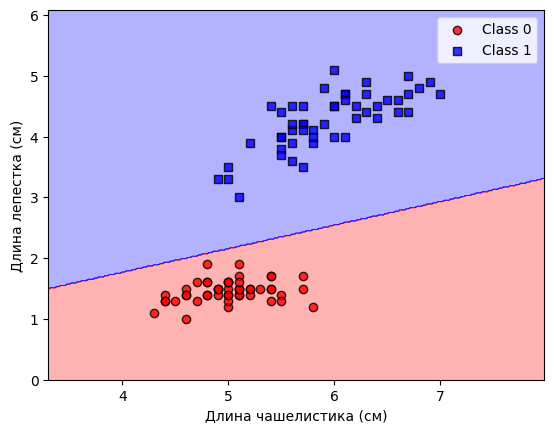

In [13]:
plot_decision_regions(X, y, classifier=ppn)
plt.xlabel('Длина чашелистика (см)')
plt.ylabel('Длина лепестка (см)')
plt.legend(loc='upper right')
plt.show()

## Adaline

In [23]:
class AdalineGD:
    
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state
    
    def fit(self, X, y):
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.b_ = np.float64(0.)
        self.losses_ = []

        for i in range(self.n_iter):
            net_input = self.net_input(X)
            output = self.activation(net_input)
            errors = (y - output)
            self.w_ += self.eta * 2.0 * X.T.dot(errors) / X.shape[0]
            self.b_ += self.eta * 2.0 * errors.mean()
            loss = (errors ** 2).mean()
            self.losses_.append(loss)

        return self

    def net_input(self, X):
        return np.dot(X, self.w_) + self.b_
    
    def activation(self, X):
        return X
    
    def predict(self, X):
        return np.where(self.activation(self.net_input(X)) >= 0.5, 1, 0)

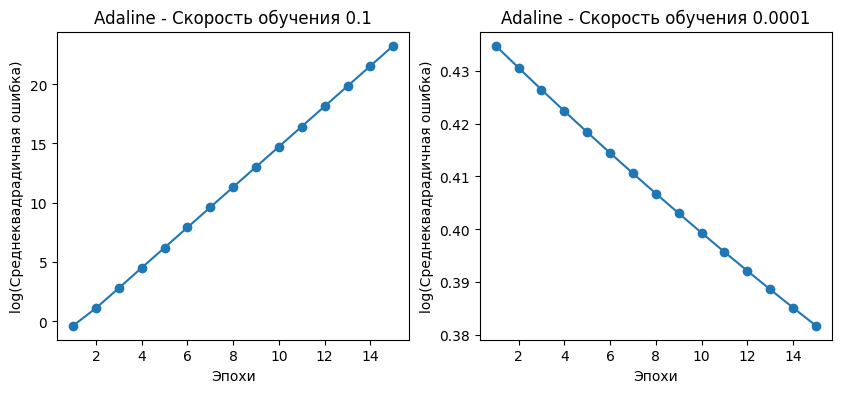

In [24]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
ada1 = AdalineGD(n_iter=15, eta=0.1).fit(X, y)

ax[0].plot(range(1, len(ada1.losses_) + 1),
           np.log10(ada1.losses_), marker='o')
ax[0].set_xlabel('Эпохи')
ax[0].set_ylabel('log(Среднеквадрадичная ошибка)')
ax[0].set_title('Adaline - Скорость обучения 0.1')

ada2 = AdalineGD(n_iter=15, eta=0.0001).fit(X, y)

ax[1].plot(range(1, len(ada2.losses_) + 1),
           ada2.losses_, marker='o')
ax[1].set_xlabel('Эпохи')
ax[1].set_ylabel('log(Среднеквадрадичная ошибка)')
ax[1].set_title('Adaline - Скорость обучения 0.0001')

plt.show()

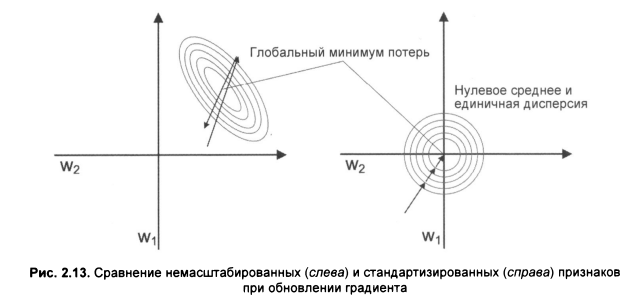

In [25]:
pd.read_csv('standartization.csv').head()

,Метод,Формула,Диапазон,Когда использовать
0,StandardScaler (стандартизация),(x - mu) / sigma,"(-inf, +inf)","Данные ~ нормальные, есть выбросы, используем ..."
1,MinMaxScaler,(x - min) / (max - min),"[0, 1] (по умолчанию)","Нужен фиксированный диапазон, данные без сильн..."
2,MinMaxScaler (custom),2 * (x - min) / (max - min) - 1,"[-1, 1]",Когда именно такой диапазон требуется архитект...
3,RobustScaler,(x - median) / (IQR),"(-inf, +inf)","Много выбросов, нужно уменьшить их влияние"


In [26]:
X_std = np.copy(X)
X_std[:, 0] = (X[:, 0] - X[:, 0].mean()) / X[:, 0].std()
X_std[:, 1] = (X[:, 1] - X[:, 1].mean()) / X[:, 1].std()

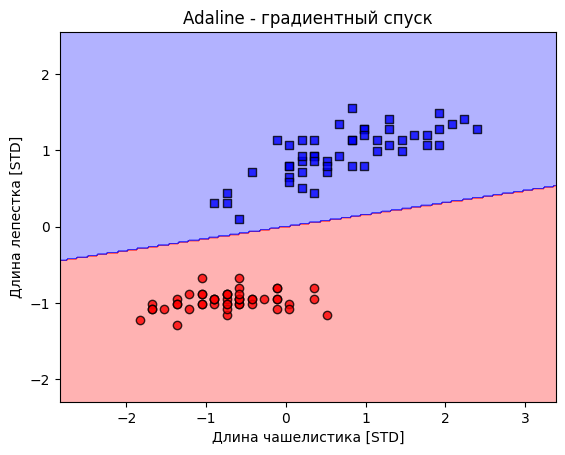

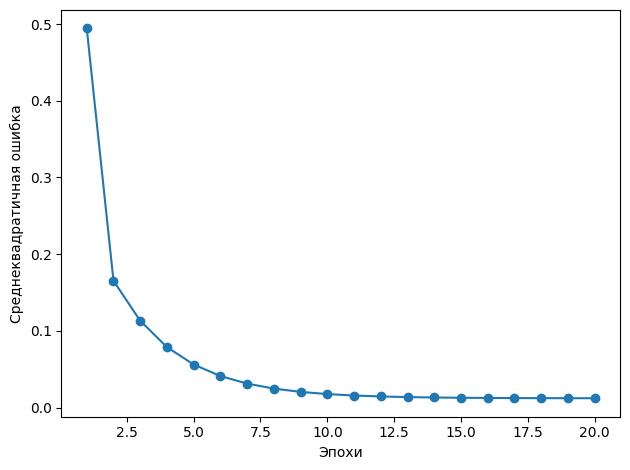

In [28]:
ada_gd = AdalineGD(n_iter=20, eta=0.5)
ada_gd.fit(X_std, y)
plot_decision_regions(X_std, y, classifier=ada_gd)
plt.title('Adaline - градиентный спуск')
plt.xlabel('Длина чашелистика [STD]')
plt.ylabel('Длина лепестка [STD]')
plt.show()

plt.plot(range(1, len(ada_gd.losses_) + 1),
         ada_gd.losses_, marker='o')
plt.xlabel('Эпохи')
plt.ylabel('Среднеквадратичная ошибка')
plt.tight_layout()
plt.show()